# **Monday-Coffee Model**

## **Importing Libraries**

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Pre-Processing Dataset**

In [35]:
df = pd.read_csv("churn_data.csv")
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [37]:
df['total_spend'] = np.round(df['avg_order_value'] * df['total_orders'],2)


In [38]:
df['churn'] = np.where(
    (df['engagement_score'] < 5.0) & 
    (df['days_since_last_purchase'] > 35) &
    (df['browsing_frequency_per_week'] < 3.5),
    1, 0
)


In [39]:
df['loyalty_member'] = df['loyalty_member'].map({'Yes': 1, 'No': 0})



In [40]:
df = df.drop(['Customer_ID','days_since_last_purchase'], axis=1)

In [41]:
df.shape

(6000, 15)

## **Model**

In [42]:
x = df.drop('churn',axis=1)
y = df['churn']

In [43]:
x

,account_age_months,avg_order_value,total_orders,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,total_spend
0,46,164.96,12,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,1979.52
1,3,39.09,4,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,156.36
2,29,37.42,8,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,299.36
3,35,62.64,9,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,563.76
4,39,113.03,1,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,113.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2,77.48,1,0.066,0.0056,1,0,7.6,0.773,4.55,6.47,8.86,3.0,77.48
5996,52,49.06,27,0.135,0.0224,0,0,1.1,0.863,5.00,5.12,9.93,3.7,1324.62
5997,8,66.12,1,0.127,0.0352,0,0,1.5,0.732,3.23,4.83,8.11,3.5,66.12
5998,4,103.95,3,0.231,0.0288,0,0,1.7,0.509,5.00,5.62,9.90,4.0,311.85


In [44]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5995    0
5996    0
5997    0
5998    0
5999    0
Name: churn, Length: 6000, dtype: int32

In [45]:
x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [46]:
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)

In [47]:
print(f"Train size: {len(x_train)}") 
print(f"Val size: {len(x_val)}")     
print(f"Test size: {len(x_test)}")  

Train size: 3600
Val size: 1200
Test size: 1200


In [48]:
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), x_train.columns)
])

In [49]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

In [50]:

xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=ratio, 
        random_state=42,
    
    ))
])


In [51]:
xgb_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [52]:
val_predictions = xgb_pipeline.predict(x_val)
print("\n--- VALIDATION RESULTS ---")
print(classification_report(y_val, val_predictions, target_names=['Stayed (0)', 'Churned (1)']))


--- VALIDATION RESULTS ---
              precision    recall  f1-score   support

  Stayed (0)       0.99      0.99      0.99       973
 Churned (1)       0.95      0.98      0.96       227

    accuracy                           0.99      1200
   macro avg       0.97      0.98      0.98      1200
weighted avg       0.99      0.99      0.99      1200



In [53]:
predictions =xgb_pipeline.predict(x_test)

In [54]:
test_predictions = xgb_pipeline.predict(x_test)
print("\n--- TEST RESULTS ---")
print(classification_report(y_test, test_predictions, target_names=['Stayed (0)', 'Churned (1)']))


--- TEST RESULTS ---
              precision    recall  f1-score   support

  Stayed (0)       1.00      0.99      1.00       990
 Churned (1)       0.96      1.00      0.98       210

    accuracy                           0.99      1200
   macro avg       0.98      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



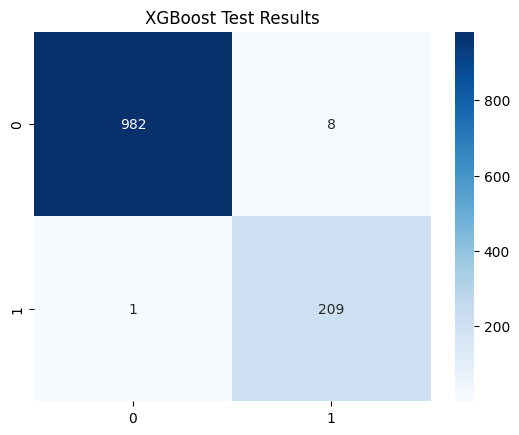

In [55]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='d', cmap='Blues',)
plt.title("XGBoost Test Results")
plt.show()

## **Feature Importance**

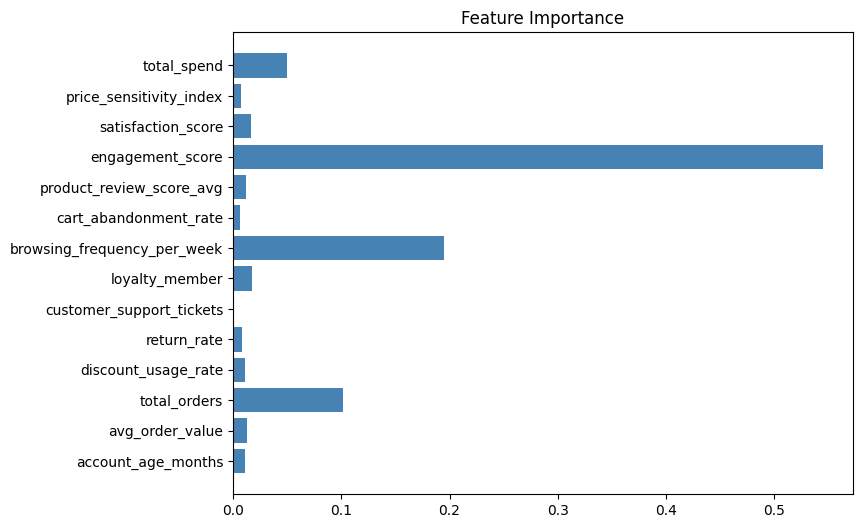

In [56]:
import matplotlib.pyplot as plt


model = xgb_pipeline[-1]


importances = model.feature_importances_


plt.figure(figsize=(8, 6))
plt.barh(x_train.columns, importances, color='steelblue')

plt.title("Feature Importance")
plt.show()

In [57]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df['Importance (%)'] = (
    importance_df['Importance'] /
    importance_df['Importance'].sum() * 100
)

print(importance_df)



                        Feature  Importance  Importance (%)
10             engagement_score    0.545388       54.538841
7   browsing_frequency_per_week    0.195233       19.523281
2                  total_orders    0.101707       10.170652
13                  total_spend    0.050245        5.024518
6                loyalty_member    0.017957        1.795665
11           satisfaction_score    0.017035        1.703518
1               avg_order_value    0.013316        1.331592
9      product_review_score_avg    0.011825        1.182496
0            account_age_months    0.011539        1.153900
3           discount_usage_rate    0.011467        1.146741
4                   return_rate    0.008512        0.851177
12      price_sensitivity_index    0.007799        0.779897
8         cart_abandonment_rate    0.006837        0.683676
5      customer_support_tickets    0.001140        0.114045


In [58]:
import joblib
joblib.dump(xgb_pipeline, 'xgb_model.pkl')

['xgb_model.pkl']